# Regression

## 1. Problem formulation
In this notebook, we'll focus on *regression*, using an example based on a real study in which data for a bicycle sharing scheme was collected and used to predict the number of rentals based on seasonality and weather conditions. We'll use a simplified version of the dataset from that study.


## 2 Data collection and labelling

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# load the training dataset
df = pd.read_csv('daily-bike-share.csv')
# df = pd.read_csv('/content/sample_data/daily-bike-share.csv') # upload CSV file in Colab,

print(df.head())

   day  mnth  year  season  holiday  weekday  workingday  weathersit  \
0    1     1  2011       1        0        6           0           2   
1    2     1  2011       1        0        0           0           2   
2    3     1  2011       1        0        1           1           1   
3    4     1  2011       1        0        2           1           1   
4    5     1  2011       1        0        3           1           1   

       temp     atemp       hum  windspeed  rentals  
0  0.344167  0.363625  0.805833   0.160446      331  
1  0.363478  0.353739  0.696087   0.248539      131  
2  0.196364  0.189405  0.437273   0.248309      120  
3  0.200000  0.212122  0.590435   0.160296      108  
4  0.226957  0.229270  0.436957   0.186900       82  


The data consists of the following columns:

- **instant**: A unique row identifier
- **day**: The date on which the data was observed - in this case, the data was collected daily; so there's one row per date.
- **mnth**: The calendar month in which the observation was made (1:January ... 12:December)
- **yr**: The year of the study in which the observation was made (the study took place over two years - year 0 represents 2011, and year 1 represents 2012)
- **season**: A numerically encoded value indicating the season (1:spring, 2:summer, 3:fall, 4:winter)
- **holiday**: A binary value indicating whether or not the observation was made on a public holiday
- **weekday**: The day of the week on which the observation was made (0:Sunday ... 6:Saturday)
- **workingday**: A binary value indicating whether or not the day is a working day (not a weekend or holiday)
- **weathersit**: A categorical value indicating the weather situation (1:clear, 2:mist/cloud, 3:light rain/snow, 4:heavy rain/hail/snow/fog)
- **temp**: The temperature in celsius (**normalized**)
- **atemp**: The apparent ("feels-like") temperature in celsius (**normalized**)
- **hum**: The humidity level (**normalized**)
- **windspeed**: The windspeed (**normalized**)
- **rentals**: The number of bicycle rentals recorded.

In this dataset, **rentals** represents the label (the *y* value) our model must be trained to predict. The other columns are potential features (*x* values).

As mentioned previously, you can perform some *feature engineering* to combine or derive new features. For example, let's add a new column named **day** to the dataframe by extracting the day component from the existing **dteday** column. The new column represents the day of the month from 1 to 31.

OK, let's start our analysis of the data by examining a few key descriptive statistics. We can use the dataframe's **describe** method to generate these for the numeric features as well as the **rentals** label column.

### Repairing Data Types
Beside missing data and missing missing data, there's another thing that can make you loos your cool, while working with data: wrong data types. When we watch the "dypes"-Attribute of one of the frames, we see that some variables have an impractical data type. For example should "workingday" be a binary variable that indicates if the day is a workingday (1) or not (0). But when the datatype is set to an integer, this can cause trouble. For example regression techniques would treat the variable as an integer instead of a binary variable.

In [58]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   day         731 non-null    int64  
 1   mnth        731 non-null    int64  
 2   year        731 non-null    int64  
 3   season      731 non-null    int64  
 4   holiday     731 non-null    int64  
 5   weekday     731 non-null    int64  
 6   workingday  731 non-null    int64  
 7   weathersit  731 non-null    int64  
 8   temp        731 non-null    float64
 9   atemp       731 non-null    float64
 10  hum         731 non-null    float64
 11  windspeed   731 non-null    float64
 12  rentals     731 non-null    int64  
dtypes: float64(4), int64(9)
memory usage: 74.4 KB
None


Because we have to repair the datatypes for both frames and we also want to learn something about programming as a side effect, we write a function for this task. It takes the dataframe, converts the variable "date" into datetime-format, all the categorial data into 'category' respectively 'bool'-format, gives meaningful names to all categories and returns a repaired frame.

In [59]:
# Fixing the datatypes 
df.loc[:,'season':'mnth'] = df.loc[:,'season':'mnth'].astype('category')
df[['holiday','workingday']] = df[['holiday','workingday']].astype('bool')
df[['weekday','weathersit']] = df[['weekday','weathersit']].astype('category')

# Get Meaningful Names for the categorial Variables
mapping_season = {1:"1_Winter", 2:"2_Spring", 3:"3_Summer", 4:"4_Fall" }
mapping_weekdays = {0:"Sunday", 1:"Monday", 2:"Tuesday", 3:"Wednesday", 
                    4:"Thursday", 5:"Friday", 6:"Saturday"}
mapping_weather = {1:"good", 2:"medium", 3:"poor", 4:"very_poor" }

df["season"] = df.season.map(mapping_season)
df["weekday"] = df.weekday.map(mapping_weekdays)
df["weathersit"] = df.weathersit.map(mapping_weather)

In [60]:
print(df.head(10))

   day  mnth  year    season  holiday    weekday  workingday weathersit  \
0    1     1  2011  1_Winter    False   Saturday       False     medium   
1    2     1  2011  1_Winter    False     Sunday       False     medium   
2    3     1  2011  1_Winter    False     Monday        True       good   
3    4     1  2011  1_Winter    False    Tuesday        True       good   
4    5     1  2011  1_Winter    False  Wednesday        True       good   
5    6     1  2011  1_Winter    False   Thursday        True       good   
6    7     1  2011  1_Winter    False     Friday        True     medium   
7    8     1  2011  1_Winter    False   Saturday       False     medium   
8    9     1  2011  1_Winter    False     Sunday       False       good   
9   10     1  2011  1_Winter    False     Monday        True       good   

       temp     atemp       hum  windspeed  rentals  
0  0.344167  0.363625  0.805833   0.160446      331  
1  0.363478  0.353739  0.696087   0.248539      131  
2  0.196364 

In [61]:
# now lets see our data types after the above change.
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   day         731 non-null    int64   
 1   mnth        731 non-null    int64   
 2   year        731 non-null    int64   
 3   season      731 non-null    object  
 4   holiday     731 non-null    bool    
 5   weekday     731 non-null    category
 6   workingday  731 non-null    bool    
 7   weathersit  731 non-null    category
 8   temp        731 non-null    float64 
 9   atemp       731 non-null    float64 
 10  hum         731 non-null    float64 
 11  windspeed   731 non-null    float64 
 12  rentals     731 non-null    int64   
dtypes: bool(2), category(2), float64(4), int64(4), object(1)
memory usage: 54.9+ KB
None


## EDA

In [62]:
# Lets see the percentage of values in column weathersit
df['weathersit'].value_counts(normalize=True)

weathersit
good      0.633379
medium    0.337893
poor      0.028728
Name: proportion, dtype: float64

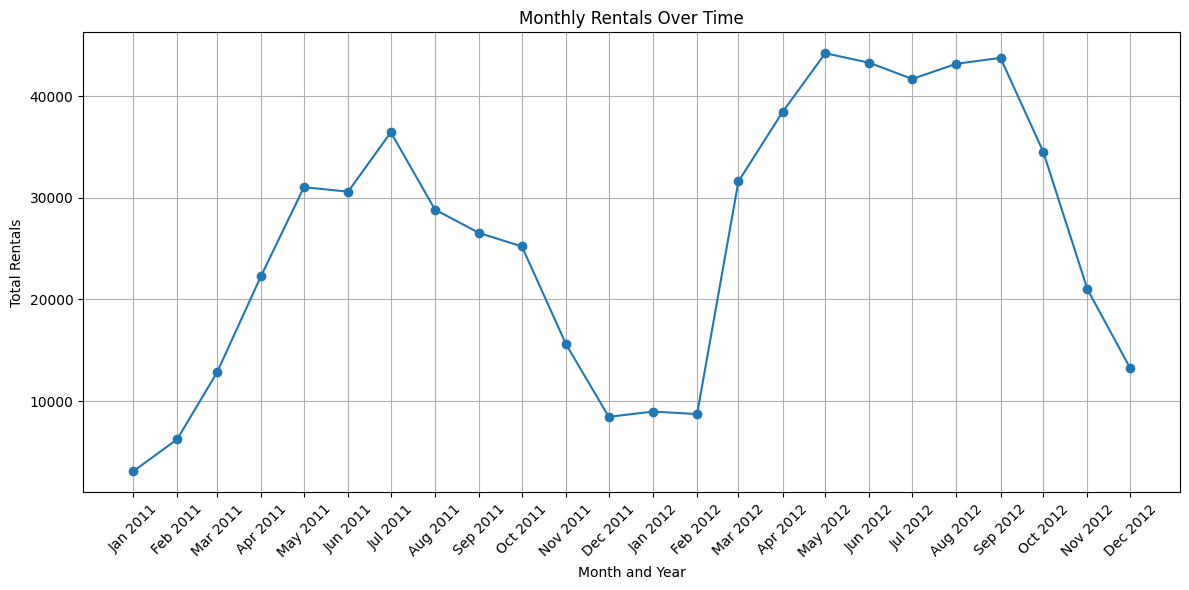

In [63]:
# Lets see how rentals vary with time

# Step 1: Create a datetime column using the correct column names
df['date'] = pd.to_datetime(df[['year', 'mnth']].rename(columns={'mnth': 'month'}).assign(day=1))

# Step 2: Group by the new 'date' and sum rentals
monthly_rentals = df.groupby('date')['rentals'].sum().reset_index()

# Step 3: Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_rentals['date'], monthly_rentals['rentals'], marker='o', linestyle='-')
plt.title('Monthly Rentals Over Time')
plt.xlabel('Month and Year')
plt.ylabel('Total Rentals')
plt.grid(True)
# Format x-axis ticks as "Jan 2011", "Feb 2011", ...
plt.xticks(ticks=monthly_rentals['date'], labels=monthly_rentals['date'].dt.strftime('%b %Y'), rotation=45)

plt.tight_layout()
plt.show()


### observation:
Seems like people don't wanted bikes in February.

In [64]:
numeric_features = ['temp', 'atemp', 'hum', 'windspeed']
df[numeric_features + ['rentals']].describe()

,temp,atemp,hum,windspeed,rentals
count,731.000000,731.000000,731.000000,731.000000,731.000000
mean,0.495385,0.474354,0.627894,0.190486,848.176471
std,0.183051,0.162961,0.142429,0.077498,686.622488
min,0.059130,0.079070,0.000000,0.022392,2.000000
25%,0.337083,0.337842,0.520000,0.134950,315.500000
50%,0.498333,0.486733,0.626667,0.180975,713.000000
75%,0.655417,0.608602,0.730209,0.233214,1096.000000
max,0.861667,0.840896,0.972500,0.507463,3410.000000


The statistics reveal some information about the distribution of the data in each of the numeric fields, including the number of observations (there are 731 records), the mean, standard deviation, minimum and maximum values, and the quartile values (the threshold values for 25%, 50% - which is also the median, and 75% of the data). From this, we can see that the mean number of daily rentals is around 848; but there's a comparatively large standard deviation, indicating a lot of variance in the number of rentals per day.

We might get a clearer idea of the distribution of rentals values by visualizing the data. Common plot types for visualizing numeric data distributions are *histograms* and *box plots*, so let's use Python's **matplotlib** library to create one of each of these for the **rentals** column.

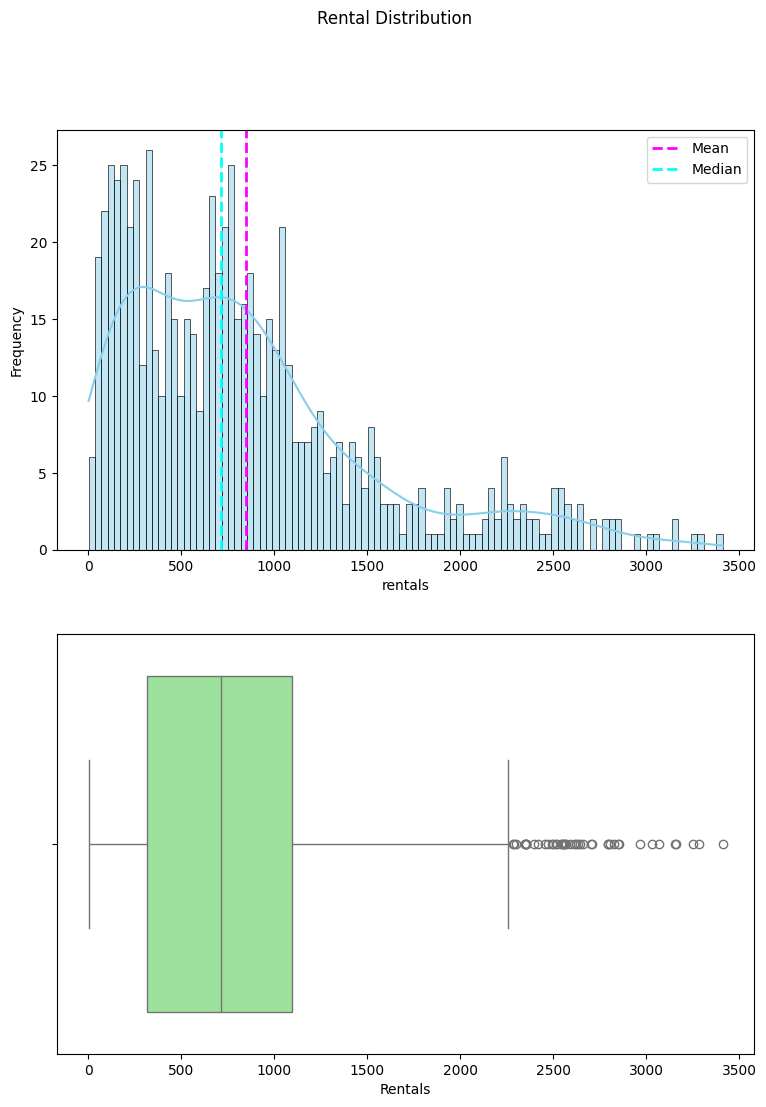

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure inline display in Jupyter
%matplotlib inline  

# Get the label column
label = df['rentals']

# Create a figure for 2 subplots (2 rows, 1 column)
fig, ax = plt.subplots(2, 1, figsize=(9, 12))

# Histogram (with KDE disabled to match your matplotlib version)
sns.histplot(label, bins=100, kde=True, ax=ax[0], color='skyblue')
ax[0].set_ylabel('Frequency')

# Add lines for mean and median
ax[0].axvline(label.mean(), color='magenta', linestyle='dashed', linewidth=2, label='Mean')
ax[0].axvline(label.median(), color='cyan', linestyle='dashed', linewidth=2, label='Median')
ax[0].legend()

# Boxplot (horizontal)
sns.boxplot(x=label, ax=ax[1], color='lightgreen')
ax[1].set_xlabel('Rentals')

# Add a title to the Figure
fig.suptitle('Rental Distribution')

plt.show()


The plots show that the number of daily rentals ranges from 0 to just over 3,400. However, the mean (and median) number of daily rentals is closer to the low end of that range, with most of the data between 0 and around 2,200 rentals. The few values above this are shown in the box plot as small circles, indicating that they are *outliers* - in other words, unusually high or low values beyond the typical range of most of the data.

We can do the same kind of visual exploration of the numeric features. Let's create a histogram for each of these.

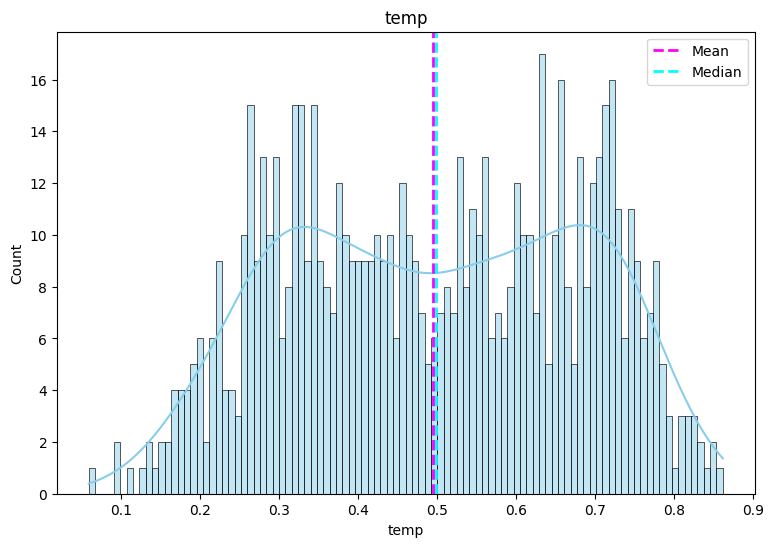

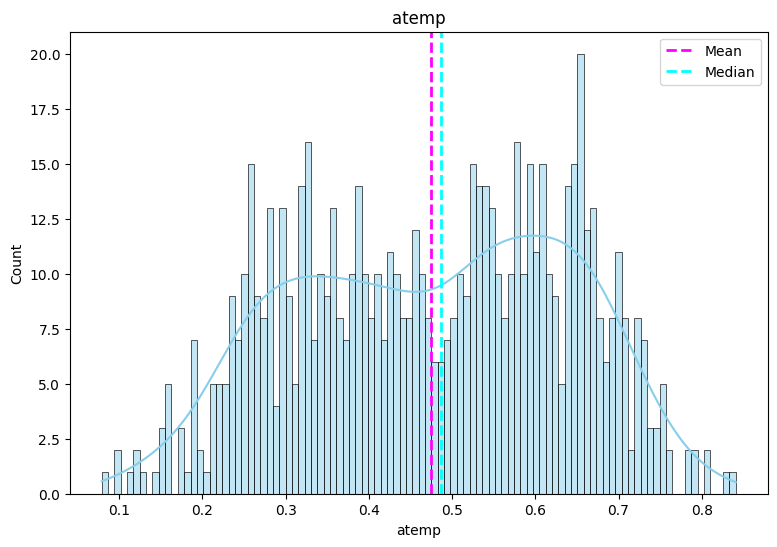

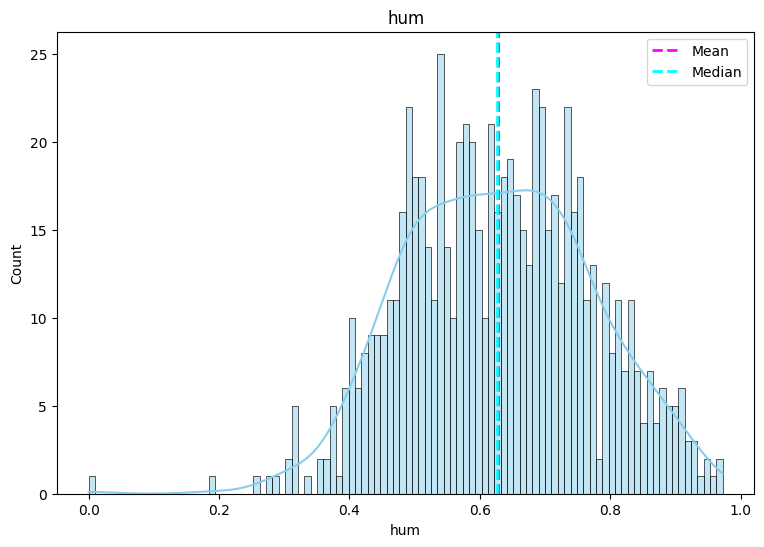

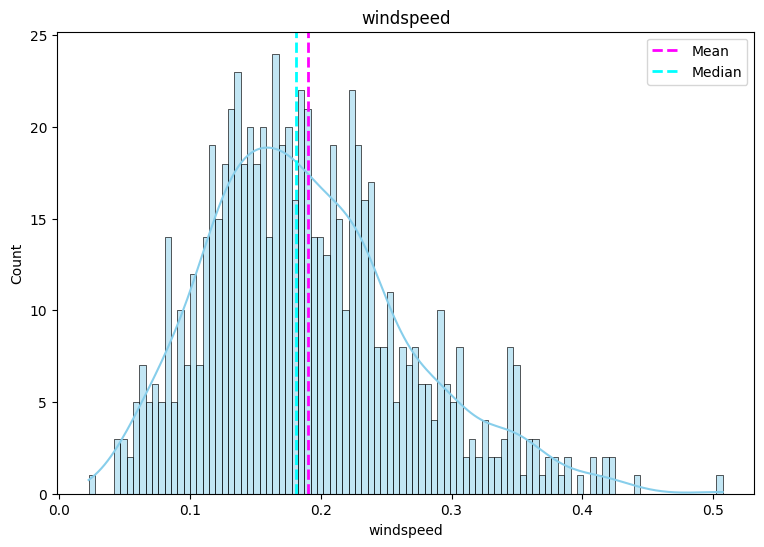

In [82]:
# Plot a histogram for each numeric feature
for col in numeric_features:
    fig, ax = plt.subplots(figsize=(9, 6))
    feature = df[col]

    # Histogram with seaborn
    sns.histplot(feature, bins=100, kde=True, ax=ax, color="skyblue")

    # Add mean and median lines
    ax.axvline(feature.mean(), color='magenta', linestyle='dashed', linewidth=2, label='Mean')
    ax.axvline(feature.median(), color='cyan', linestyle='dashed', linewidth=2, label='Median')

    # Title and legend
    ax.set_title(col)
    ax.legend()

plt.show()

The numeric features seem to be more *normally* distributed, with the mean and median nearer the middle of the range of values, coinciding with where the most commonly occurring values are.

> **Note**: The distributions are not truly *normal* in the statistical sense, which would result in a smooth, symmetric "bell-curve" histogram with the mean and mode (the most common value) in the center; but they do generally indicate that most of the observations have a value somewhere near the middle.

We've explored the distribution of the numeric values in the dataset, but what about the categorical features? These aren't continuous numbers on a scale, so we can't use histograms; but we can plot a bar chart showing the count of each discrete value for each category.

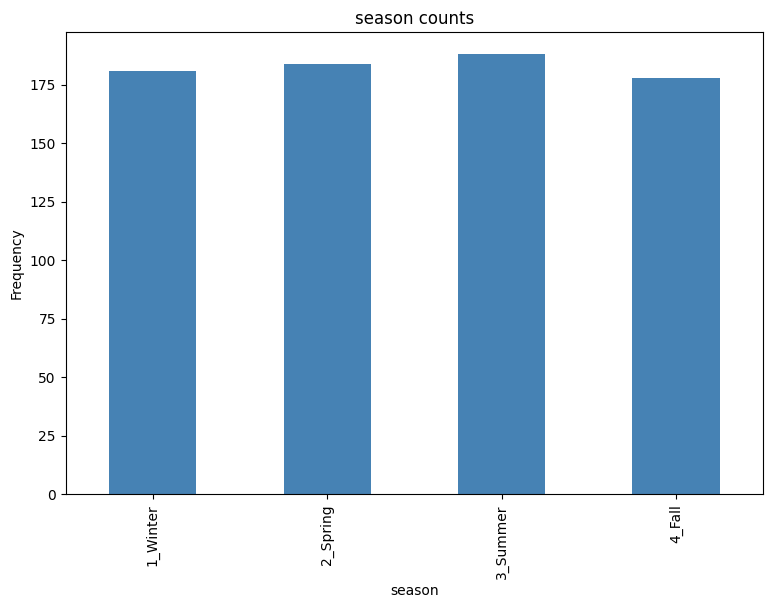

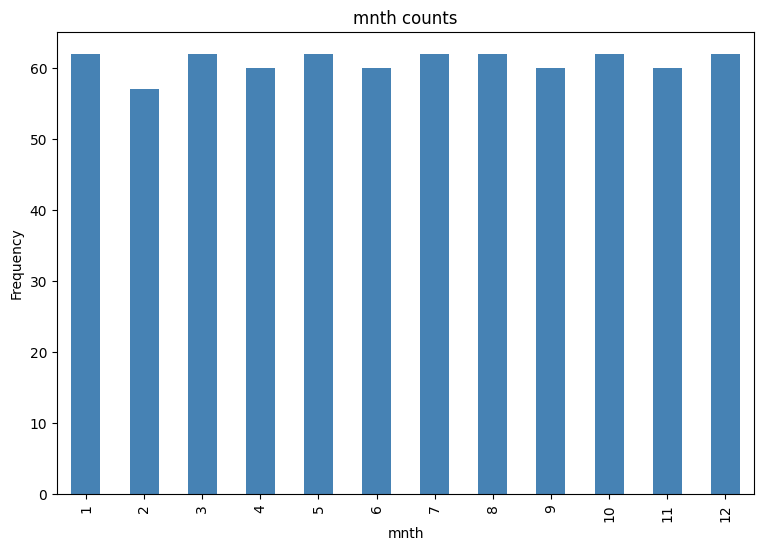

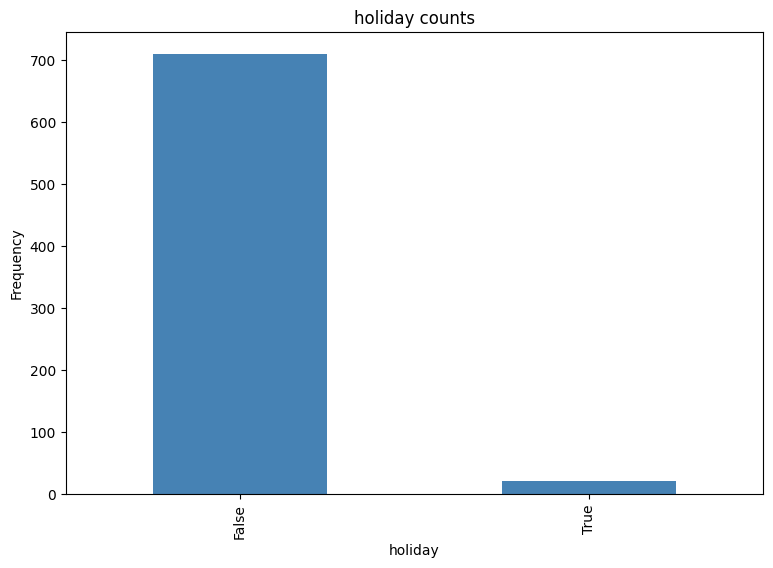

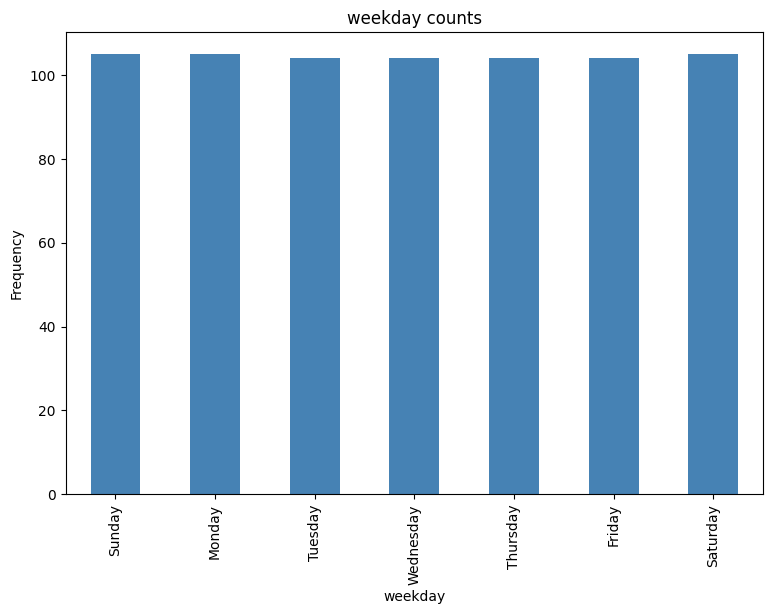

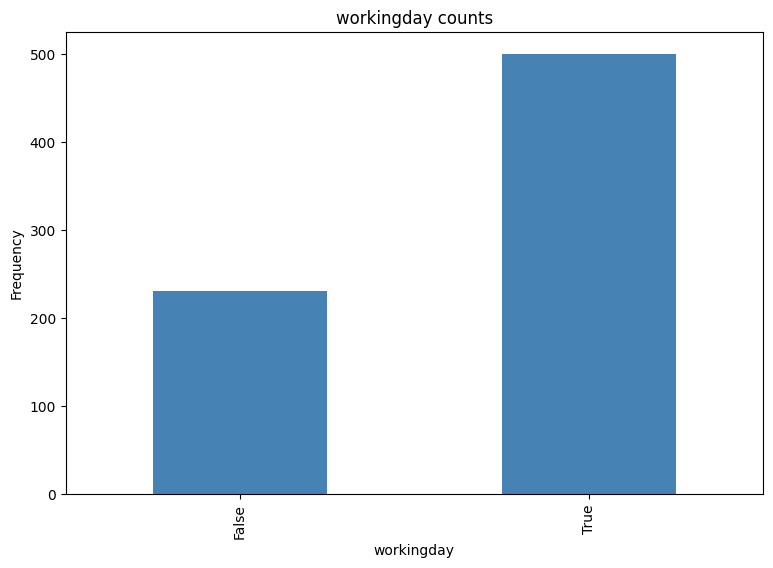

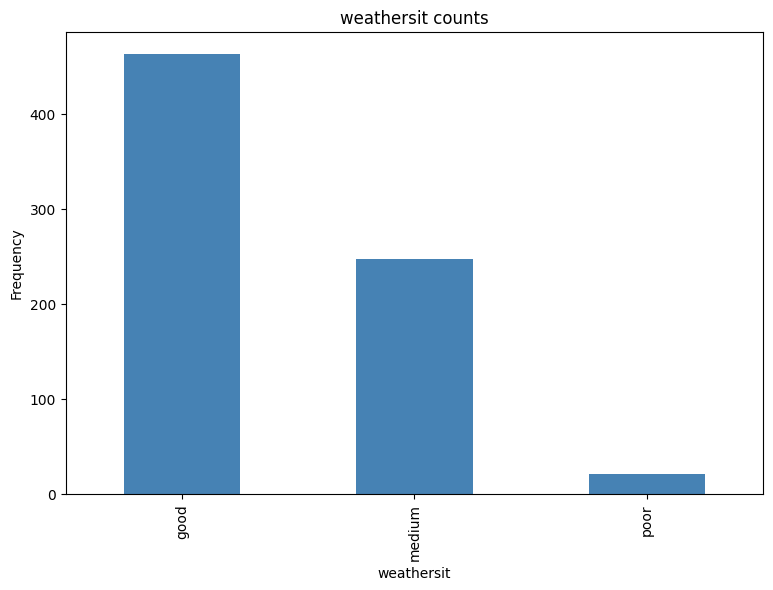

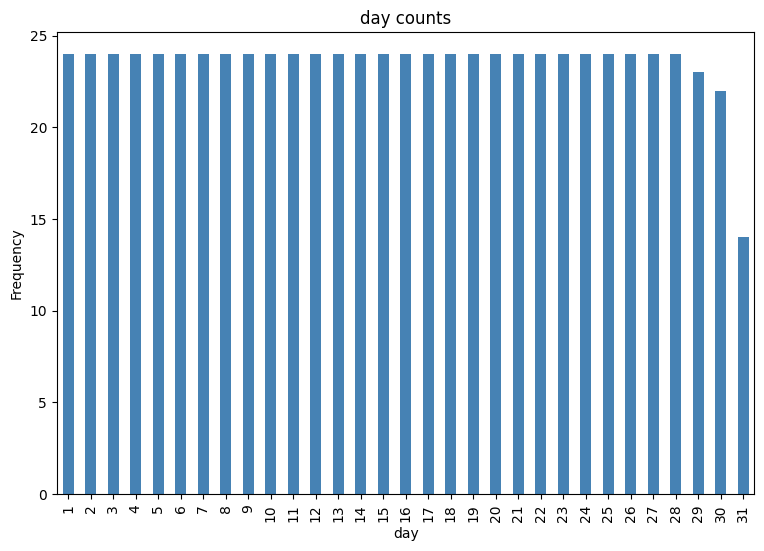

In [68]:

# plot a bar plot for each categorical feature count
categorical_features = ['season','mnth','holiday','weekday','workingday','weathersit', 'day']

for col in categorical_features:
    counts = df[col].value_counts().sort_index()
    fig = plt.figure(figsize=(9, 6))
    ax = fig.gca()
    counts.plot.bar(ax = ax, color='steelblue')
    ax.set_title(col + ' counts')
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
plt.show()


Many of the categorical features show a more or less *uniform* distribution (meaning there's roughly the same number of rows for each category). Exceptions to this include:

- **holiday**: There are many fewer days that are holidays than days that aren't.
- **workingday**: There are more working days than non-working days.
- **weathersit**: Most days are category *1* (clear), with category *2* (mist and cloud) the next most common. There are comparatively few category *3* (light rain or snow) days, and no category *4* (heavy rain, hail, or fog) days at all.

Now that we know something about the distribution of the data in our columns, we can start to look for relationships between the features and the **rentals** label we want to be able to predict.

For the numeric features, we can create scatter plots that show the intersection of feature and label values. We can also calculate the *correlation* statistic to quantify the apparent relationship..

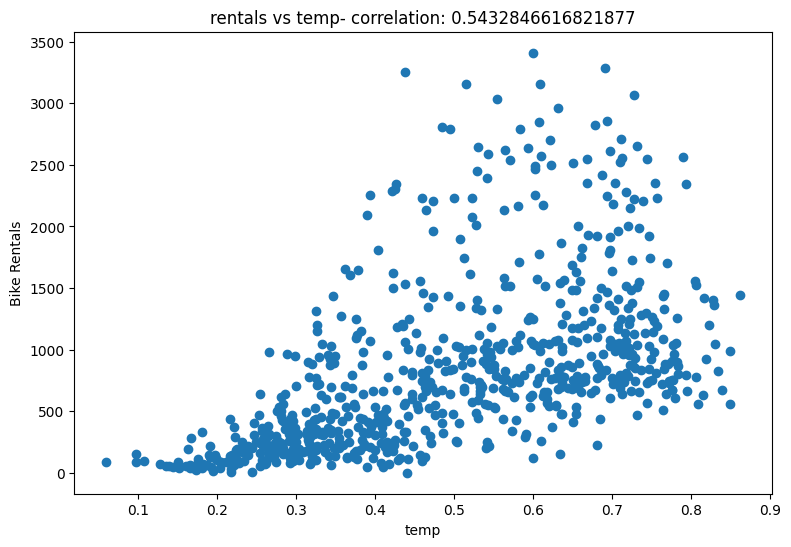

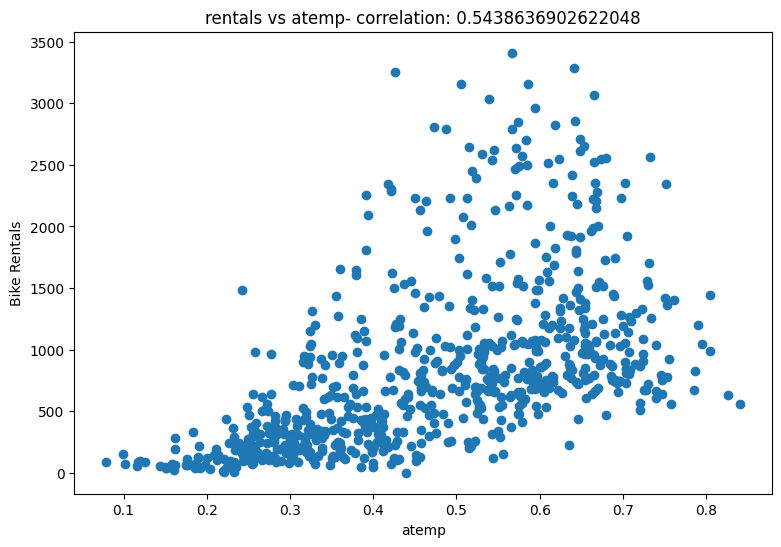

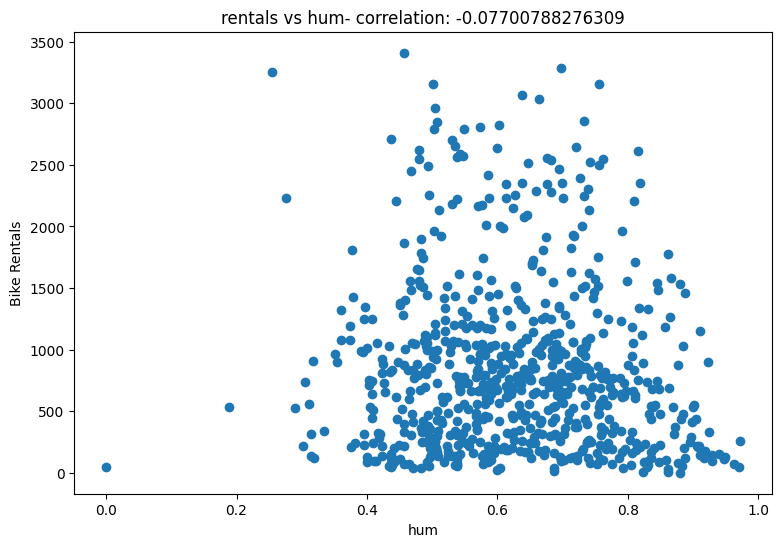

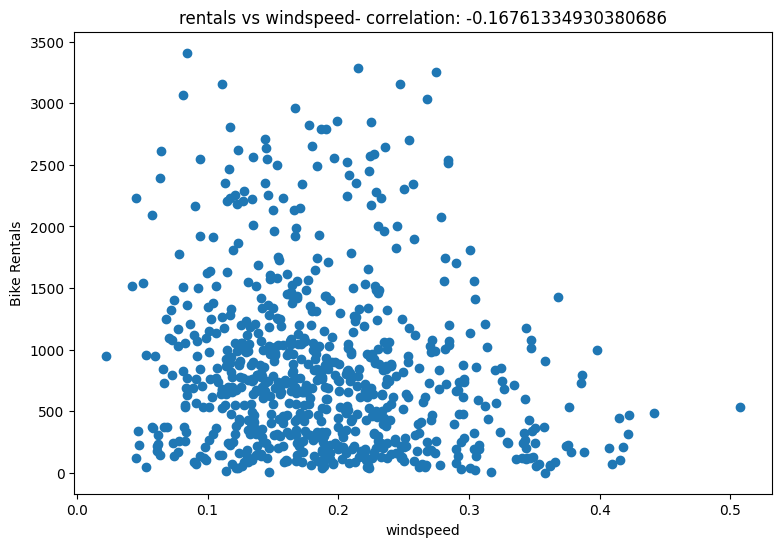

In [69]:
for col in numeric_features:
    fig = plt.figure(figsize=(9, 6))
    ax = fig.gca()
    feature = df[col]
    label = df['rentals']
    correlation = feature.corr(label)
    plt.scatter(x=feature, y=label)
    plt.xlabel(col)
    plt.ylabel('Bike Rentals')
    ax.set_title('rentals vs ' + col + '- correlation: ' + str(correlation))
plt.show()


The results aren't conclusive, but if you look closely at the scatter plots for **temp** and **atemp**, you can see a vague diagonal trend showing that higher rental counts tend to coincide with higher temperatures; and a correlation value of just over 0.5 for both of these features supports this observation. Conversely, the plots for **hum** and **windspeed** show a slightly negative correlation, indicating that there are fewer rentals on days with high humidity or windspeed.

Now let's compare the categorical features to the label. We'll do this by creating box plots that show the distribution of rental counts for each category.

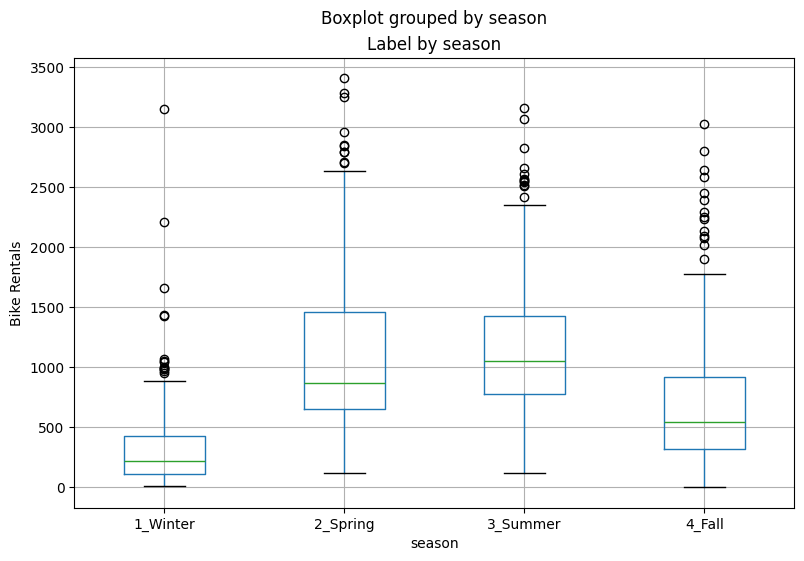

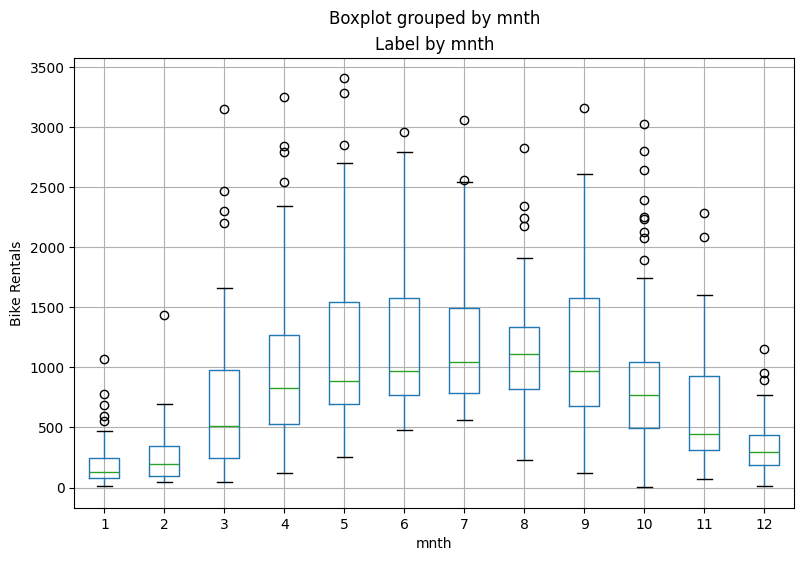

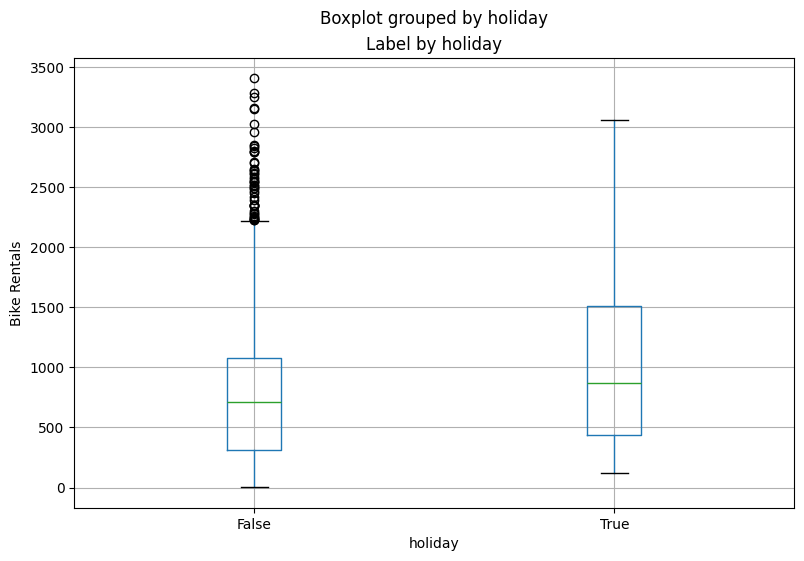

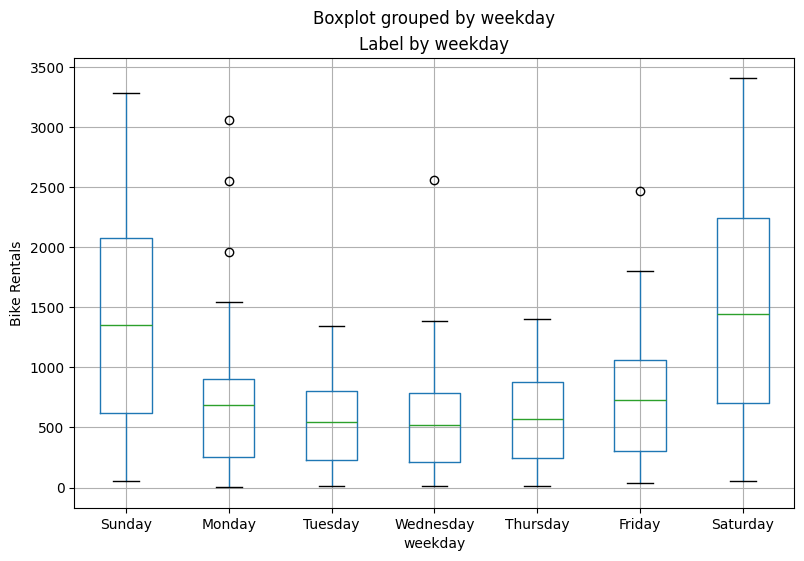

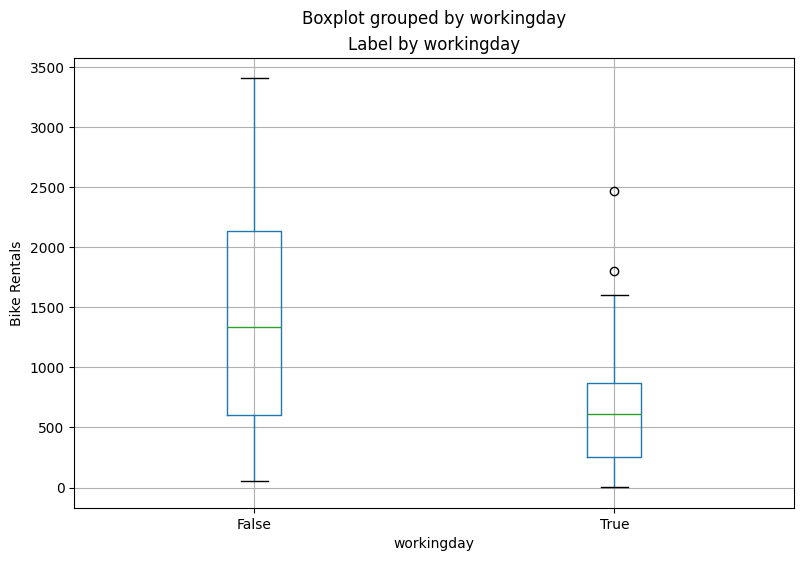

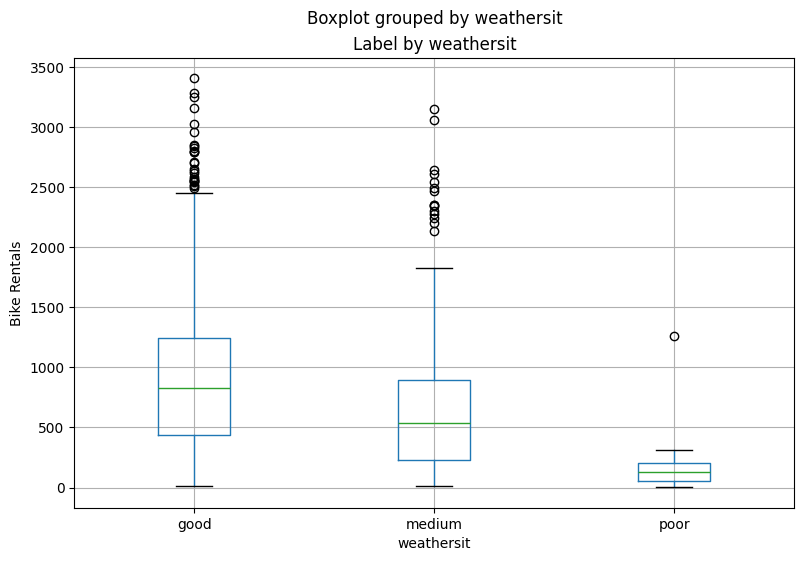

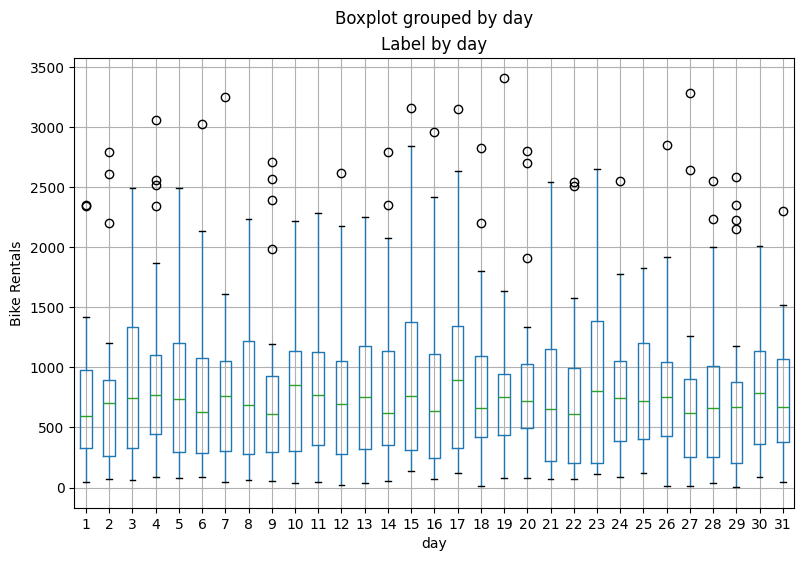

In [70]:
# plot a boxplot for the label by each categorical feature
for col in categorical_features:
    fig = plt.figure(figsize=(9, 6))
    ax = fig.gca()
    df.boxplot(column = 'rentals', by = col, ax = ax)
    ax.set_title('Label by ' + col)
    ax.set_ylabel("Bike Rentals")
plt.show()

The plots show some variance in the relationship between some category values and rentals. For example, there's a clear difference in the distribution of rentals on weekends (**weekday** 0 or 6) and those during the working week (**weekday** 1 to 5). Similarly, there are notable differences for **holiday** and **workingday** categories. There's a noticeable trend that shows different rental distributions in summer and fall months compared to spring and winter months. The **weathersit** category also seems to make a difference in rental distribution. The **day** feature we created for the day of the month shows little variation, indicating that it's probably not predictive of the number of rentals.

# Lets find correlation among each numeric columns: 

In [71]:
# Compute correlation matrix (only numeric columns are considered)
numeric_columns = ["temp", "atemp", "hum", "windspeed", "rentals"]
corr_matrix = df[numeric_columns].corr(method="pearson")

print(corr_matrix)

               temp     atemp       hum  windspeed   rentals
temp       1.000000  0.991702  0.126963  -0.157944  0.543285
atemp      0.991702  1.000000  0.139988  -0.183643  0.543864
hum        0.126963  0.139988  1.000000  -0.248489 -0.077008
windspeed -0.157944 -0.183643 -0.248489   1.000000 -0.167613
rentals    0.543285  0.543864 -0.077008  -0.167613  1.000000


# Rentals by working day

In [72]:
print(df.groupby("workingday")["rentals"].describe())


            count         mean         std   min    25%     50%      75%  \
workingday                                                                 
False       231.0  1371.134199  873.064794  54.0  607.5  1338.0  2133.50   
True        500.0   606.570000  391.496032   2.0  251.5   616.5   872.75   

               max  
workingday          
False       3410.0  
True        2469.0  


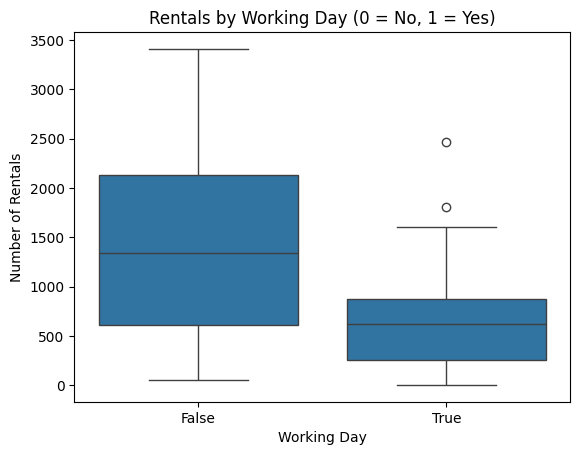

In [73]:

sns.boxplot(x="workingday", y="rentals", data=df)
plt.title("Rentals by Working Day (0 = No, 1 = Yes)")
plt.xlabel("Working Day")
plt.ylabel("Number of Rentals")
plt.show()


In [74]:
from scipy.stats import ttest_ind

rentals_working = df[df["workingday"] == 1]["rentals"]
rentals_nonworking = df[df["workingday"] == 0]["rentals"]

t_stat, p_val = ttest_ind(rentals_working, rentals_nonworking, equal_var=False)
print("T-statistic:", t_stat, "P-value:", p_val)

# Here p_val < 0.05, so the difference between working and non-working days is statistically significant.

T-statistic: -12.731622932462022 P-value: 1.7859996470148994e-29


In [75]:
# rentals by season

In [76]:
print(df.groupby("season")["rentals"].describe())

          count         mean         std    min     25%     50%      75%  \
season                                                                     
1_Winter  181.0   334.928177  387.655561    9.0  109.00   218.0   424.00   
2_Spring  184.0  1106.097826  737.590829  120.0  650.25   867.0  1463.25   
3_Summer  188.0  1202.611702  595.975032  118.0  781.75  1050.5  1424.00   
4_Fall    178.0   729.112360  606.318118    2.0  318.50   544.5   922.00   

             max  
season            
1_Winter  3155.0  
2_Spring  3410.0  
3_Summer  3160.0  
4_Fall    3031.0  


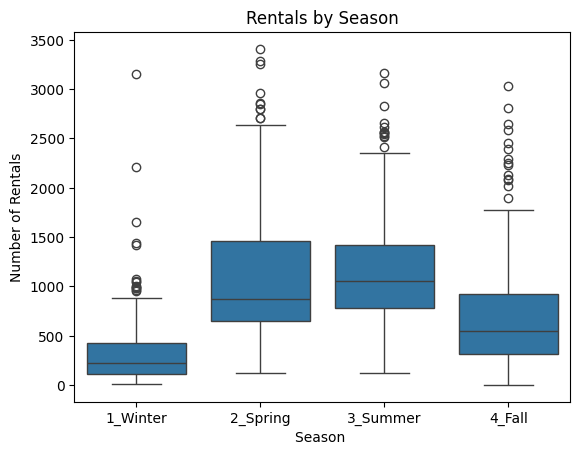

In [77]:
# Rentals by Season

sns.boxplot(x="season", y="rentals", data=df)
plt.title("Rentals by Season")
plt.xlabel("Season ")
plt.ylabel("Number of Rentals")
plt.show()

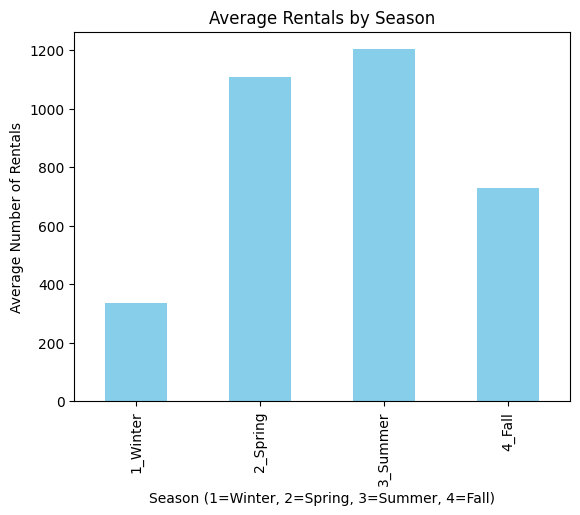

In [78]:
# Average Rentals by Season

df.groupby("season")["rentals"].mean().plot(kind="bar", color="skyblue")
plt.title("Average Rentals by Season")
plt.xlabel("Season (1=Winter, 2=Spring, 3=Summer, 4=Fall)")
plt.ylabel("Average Number of Rentals")
plt.show()

## EXTRA: KDE versus Normal Distribution
- Check how well your rental (KDE curve) matches a normal distribution.

### 1) Visual Comparison (Quick Check)

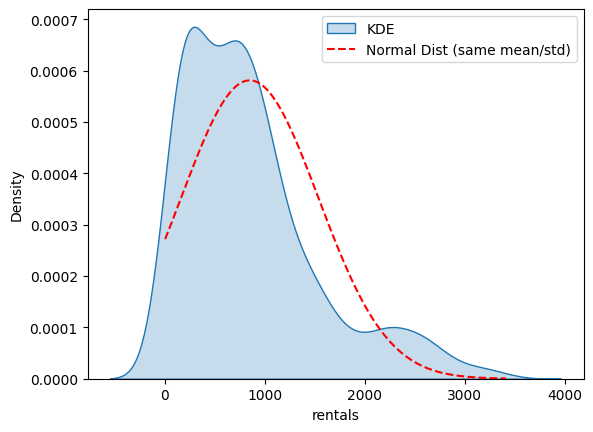

In [83]:
from scipy.stats import norm

feature = df['rentals']  # example column

# Plot KDE
sns.kdeplot(feature, label='KDE', fill=True)

# Generate normal distribution with same mean & std
x = np.linspace(feature.min(), feature.max(), 1000)
p = norm.pdf(x, feature.mean(), feature.std())

# Overlay normal curve
plt.plot(x, p, 'r--', label='Normal Dist (same mean/std)')

plt.legend()
plt.show()


### 2) Statistical Tests (Quantitative Check)

In [89]:
# 2.1) Shapiro-Wilk Test
from scipy.stats import shapiro

stat, p = shapiro(feature)
print("Shapiro-Wilk Test: stat=%.6f, p=%.15f" % (stat, p))

# p > 0.05 -> data looks Gaussian
# p < 0.05 -> reject normality

Shapiro-Wilk Test: stat=0.885015, p=0.000000000000000


In [88]:
# 2.2) Kolmogorov-Smirnov Test
from scipy.stats import kstest

stat, p = kstest(feature, 'norm', args=(feature.mean(), feature.std()))
print("K-S Test: stat=%.3f, p=%.10f" % (stat, p))

# p > 0.05 -> data looks Gaussian
# p < 0.05 -> reject normality

K-S Test: stat=0.114, p=0.0000000111


### 3) Q-Q Plot (Visual + Quantitative)

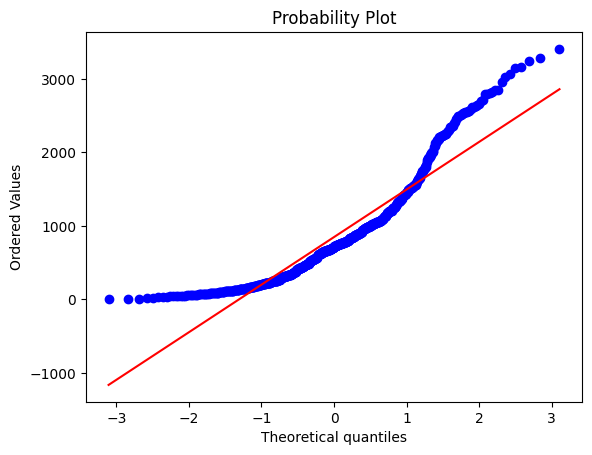

In [90]:
# Q-Q (quantile-quantile) plots show how close your data quantiles are to normal distribution quantiles:
import scipy.stats as stats

stats.probplot(feature, dist="norm", plot=plt)
plt.show()

# If points lie close to the straight diagonal, your data is approximately normal.
# We see that data is not normal.